<a href="https://colab.research.google.com/github/MATHONSIMM/Data-Science-Projects/blob/master/Credit_Risk_Model_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

Step 2: Load the Datasets

We will load the Statlog (Australian Credit Approval) and Statlog (German Credit Data) datasets from the UCI Machine Learning Repository.

In [ ]:
import pandas as pd

# Load Australian Credit Dataset
australian_credit_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
column_names_australian = ["A" + str(i) for i in range(1, 15)] + ["Class"]
australian_credit = pd.read_csv(australian_credit_url, header=None, names=column_names_australian, delim_whitespace=True)

# Load German Credit Dataset
german_credit_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
column_names_german = ["Status", "Duration", "CreditHistory", "Purpose", "CreditAmount", "Savings", "Employment", "InstallRate",
                       "PersonalStatus", "Debtors", "PresentResidence", "Property", "Age", "OtherPlans", "Housing",
                       "ExistingCredits", "Job", "NumPeopleLiable", "Telephone", "ForeignWorker", "Class"]
german_credit = pd.read_csv(german_credit_url, header=None, names=column_names_german, delim_whitespace=True)

# Display first few rows
print("Australian Credit Data:")
print(australian_credit.head())

print("\nGerman Credit Data:")
print(german_credit.head())


<ipython-input-2-cdd92acd9d71>:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  australian_credit = pd.read_csv(australian_credit_url, header=None, names=column_names_australian, delim_whitespace=True)
<ipython-input-2-cdd92acd9d71>:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  german_credit = pd.read_csv(german_credit_url, header=None, names=column_names_german, delim_whitespace=True)


Australian Credit Data:
   A1     A2     A3  A4  A5  A6     A7  A8  A9  A10  A11  A12  A13   A14  \
0   1  22.08  11.46   2   4   4  1.585   0   0    0    1    2  100  1213   
1   0  22.67   7.00   2   8   4  0.165   0   0    0    0    2  160     1   
2   0  29.58   1.75   1   4   4  1.250   0   0    0    1    2  280     1   
3   0  21.67  11.50   1   5   3  0.000   1   1   11    1    2    0     1   
4   1  20.17   8.17   2   6   4  1.960   1   1   14    0    2   60   159   

   Class  
0      0  
1      0  
2      0  
3      1  
4      1  

German Credit Data:
  Status  Duration CreditHistory Purpose  CreditAmount Savings Employment  \
0    A11         6           A34     A43          1169     A65        A75   
1    A12        48           A32     A43          5951     A61        A73   
2    A14        12           A34     A46          2096     A61        A74   
3    A11        42           A32     A42          7882     A61        A74   
4    A11        24           A33     A40       

Step 3: Data Overview & Basic Statistics

We check for missing values, class distribution, and dataset information.

In [ ]:
# Check for missing values
print("\nMissing values in Australian Credit Dataset:")
print(australian_credit.isnull().sum())

print("\nMissing values in German Credit Dataset:")
print(german_credit.isnull().sum())

# Class distribution
print("\nClass Distribution (Australian Credit Approval):")
print(australian_credit['Class'].value_counts())

print("\nClass Distribution (German Credit Data):")
print(german_credit['Class'].value_counts())

# Summary Statistics
print("\nAustralian Credit Summary:")
print(australian_credit.describe())

print("\nGerman Credit Summary:")
print(german_credit.describe())



Missing values in Australian Credit Dataset:
A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
A10      0
A11      0
A12      0
A13      0
A14      0
Class    0
dtype: int64

Missing values in German Credit Dataset:
Status              0
Duration            0
CreditHistory       0
Purpose             0
CreditAmount        0
Savings             0
Employment          0
InstallRate         0
PersonalStatus      0
Debtors             0
PresentResidence    0
Property            0
Age                 0
OtherPlans          0
Housing             0
ExistingCredits     0
Job                 0
NumPeopleLiable     0
Telephone           0
ForeignWorker       0
Class               0
dtype: int64

Class Distribution (Australian Credit Approval):
Class
0    383
1    307
Name: count, dtype: int64

Class Distribution (German Credit Data):
Class
1    700
2    300
Name: count, dtype: int64

Australian Credit Summary:
               A1          A2          

Step 4: Data Visualization

We visualize the target variable distribution and key features.

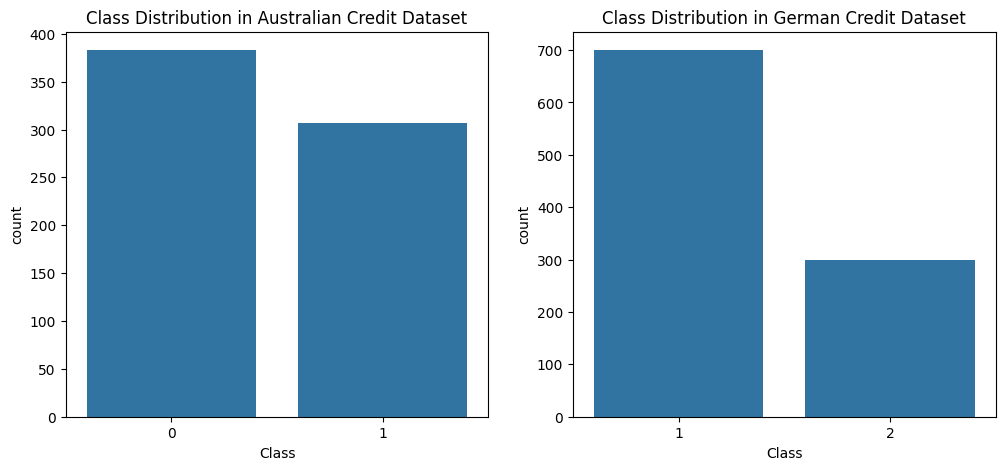

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Class', data=australian_credit, ax=axes[0])
axes[0].set_title("Class Distribution in Australian Credit Dataset")

sns.countplot(x='Class', data=german_credit, ax=axes[1])
axes[1].set_title("Class Distribution in German Credit Dataset")

plt.show()

Step 5: Feature Encoding & Data Preprocessing

We convert categorical features to numerical values for modeling

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables in German dataset
categorical_columns_german = ['Status', 'CreditHistory', 'Purpose', 'Savings', 'Employment',
                              'PersonalStatus', 'Debtors', 'Property', 'OtherPlans', 'Housing',
                              'Job', 'Telephone', 'ForeignWorker']

for col in categorical_columns_german:
    le = LabelEncoder()
    german_credit[col] = le.fit_transform(german_credit[col])

# Encode categorical variables in Australian dataset (if applicable)
categorical_columns_australian = ["A" + str(i) for i in range(1, 15) if australian_credit.dtypes[i-1] == "object"]

for col in categorical_columns_australian:
    le = LabelEncoder()
    australian_credit[col] = le.fit_transform(australian_credit[col])

print("\nEncoded Australian Credit Data:")
print(australian_credit.head())

print("\nEncoded German Credit Data:")
print(german_credit.head())


Encoded Australian Credit Data:
   A1     A2     A3  A4  A5  A6     A7  A8  A9  A10  A11  A12  A13   A14  \
0   1  22.08  11.46   2   4   4  1.585   0   0    0    1    2  100  1213   
1   0  22.67   7.00   2   8   4  0.165   0   0    0    0    2  160     1   
2   0  29.58   1.75   1   4   4  1.250   0   0    0    1    2  280     1   
3   0  21.67  11.50   1   5   3  0.000   1   1   11    1    2    0     1   
4   1  20.17   8.17   2   6   4  1.960   1   1   14    0    2   60   159   

   Class  
0      0  
1      0  
2      0  
3      1  
4      1  

Encoded German Credit Data:
   Status  Duration  CreditHistory  Purpose  CreditAmount  Savings  \
0       0         6              4        4          1169        4   
1       1        48              2        4          5951        0   
2       3        12              4        7          2096        0   
3       0        42              2        3          7882        0   
4       0        24              3        0          4870        

<ipython-input-5-ad2f9e94738f>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  categorical_columns_australian = ["A" + str(i) for i in range(1, 15) if australian_credit.dtypes[i-1] == "object"]
<ipython-input-5-ad2f9e94738f>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  categorical_columns_australian = ["A" + str(i) for i in range(1, 15) if australian_credit.dtypes[i-1] == "object"]
<ipython-input-5-ad2f9e94738f>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

Step 6: Train a Credit Risk Classification Model

We will use Logistic Regression as a baseline model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare features and target
X_australian = australian_credit.drop(columns=['Class'])
y_australian = australian_credit['Class']

X_german = german_credit.drop(columns=['Class'])
y_german = german_credit['Class']

# Split datasets into training and testing sets
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_australian, y_australian, test_size=0.2, random_state=42)
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_german, y_german, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_a = scaler.fit_transform(X_train_a)
X_test_a = scaler.transform(X_test_a)
X_train_g = scaler.fit_transform(X_train_g)
X_test_g = scaler.transform(X_test_g)

# Train Logistic Regression Models
model_australian = LogisticRegression()
model_australian.fit(X_train_a, y_train_a)

model_german = LogisticRegression()
model_german.fit(X_train_g, y_train_g)

# Predictions
y_pred_a = model_australian.predict(X_test_a)
y_pred_g = model_german.predict(X_test_g)

# Evaluate Performance
print("\nAustralian Credit Model Performance:")
print("Accuracy:", accuracy_score(y_test_a, y_pred_a))
print(classification_report(y_test_a, y_pred_a))

print("\nGerman Credit Model Performance:")
print("Accuracy:", accuracy_score(y_test_g, y_pred_g))
print(classification_report(y_test_g, y_pred_g))


Australian Credit Model Performance:
Accuracy: 0.8768115942028986
              precision    recall  f1-score   support

           0       0.91      0.90      0.90        87
           1       0.83      0.84      0.83        51

    accuracy                           0.88       138
   macro avg       0.87      0.87      0.87       138
weighted avg       0.88      0.88      0.88       138


German Credit Model Performance:
Accuracy: 0.78
              precision    recall  f1-score   support

           1       0.81      0.90      0.85       141
           2       0.67      0.49      0.57        59

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200



Advanced models for credit risk classification, using Random Forest, Gradient Boosting (GBM), and XGBoost.


Step 1: Install Additional Libraries
Ensure you have the required libraries installed:

In [ ]:
!pip install xgboost scikit-learn

Step 2: Train and Evaluate Advanced Models

We will use:


*   Random Forest Classifier – A tree-based ensemble model.
*   Gradient Boosting Classifier – A boosting algorithm that improves predictions iteratively.
*   XGBoost Classifier – A highly optimized gradient boosting algorithm.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize models
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
gradient_boosting = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgboost = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train models on Australian Credit Data
random_forest.fit(X_train_a, y_train_a)
gradient_boosting.fit(X_train_a, y_train_a)
xgboost.fit(X_train_a, y_train_a)

# Predictions
y_pred_rf_a = random_forest.predict(X_test_a)
y_pred_gb_a = gradient_boosting.predict(X_test_a)
y_pred_xgb_a = xgboost.predict(X_test_a)

# Performance Evaluation - Australian Credit Data
print("\n=== Australian Credit Model Performance ===")
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test_a, y_pred_rf_a))
print(classification_report(y_test_a, y_pred_rf_a))

print("Gradient Boosting:")
print("Accuracy:", accuracy_score(y_test_a, y_pred_gb_a))
print(classification_report(y_test_a, y_pred_gb_a))

print("XGBoost:")
print("Accuracy:", accuracy_score(y_test_a, y_pred_xgb_a))
print(classification_report(y_test_a, y_pred_xgb_a))

# Adjust class labels for the German dataset
y_train_g = y_train_g.replace({2: 1, 1: 0})
y_test_g = y_test_g.replace({2: 1, 1: 0})

# Train models on the corrected German Credit Data
random_forest.fit(X_train_g, y_train_g)
gradient_boosting.fit(X_train_g, y_train_g)
xgboost.fit(X_train_g, y_train_g)  # This should now work correctly

# Predictions
y_pred_rf_g = random_forest.predict(X_test_g)
y_pred_gb_g = gradient_boosting.predict(X_test_g)
y_pred_xgb_g = xgboost.predict(X_test_g)

# Performance Evaluation - German Credit Data
print("\n=== German Credit Model Performance (After Fix) ===")
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test_g, y_pred_rf_g))
print(classification_report(y_test_g, y_pred_rf_g))

print("Gradient Boosting:")
print("Accuracy:", accuracy_score(y_test_g, y_pred_gb_g))
print(classification_report(y_test_g, y_pred_gb_g))

print("XGBoost:")
print("Accuracy:", accuracy_score(y_test_g, y_pred_xgb_g))
print(classification_report(y_test_g, y_pred_xgb_g))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:23:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== Australian Credit Model Performance ===
Random Forest:
Accuracy: 0.8768115942028986
              precision    recall  f1-score   support

           0       0.88      0.93      0.91        87
           1       0.87      0.78      0.82        51

    accuracy                           0.88       138
   macro avg       0.88      0.86      0.86       138
weighted avg       0.88      0.88      0.88       138

Gradient Boosting:
Accuracy: 0.8768115942028986
              precision    recall  f1-score   support

           0       0.89      0.92      0.90        87
           1       0.85      0.80      0.83        51

    accuracy                           0.88       138
   macro avg       0.87      0.86      0.87       138
weighted avg       0.88      0.88      0.88       138

XGBoost:
Accuracy: 0.8623188405797102
              precision    recall  f1-score   support

           0       0.89      0.90      0.89        87
           1       0.82      0.80      0.81        51

    acc

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:23:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== German Credit Model Performance (After Fix) ===
Random Forest:
Accuracy: 0.815
              precision    recall  f1-score   support

           0       0.82      0.94      0.88       141
           1       0.79      0.51      0.62        59

    accuracy                           0.81       200
   macro avg       0.81      0.73      0.75       200
weighted avg       0.81      0.81      0.80       200

Gradient Boosting:
Accuracy: 0.785
              precision    recall  f1-score   support

           0       0.81      0.90      0.86       141
           1       0.68      0.51      0.58        59

    accuracy                           0.79       200
   macro avg       0.75      0.70      0.72       200
weighted avg       0.78      0.79      0.77       200

XGBoost:
Accuracy: 0.785
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       141
           1       0.66      0.56      0.61        59

    accuracy                          

Step 3: Model Comparison

Now, let's compare the model performances visually.


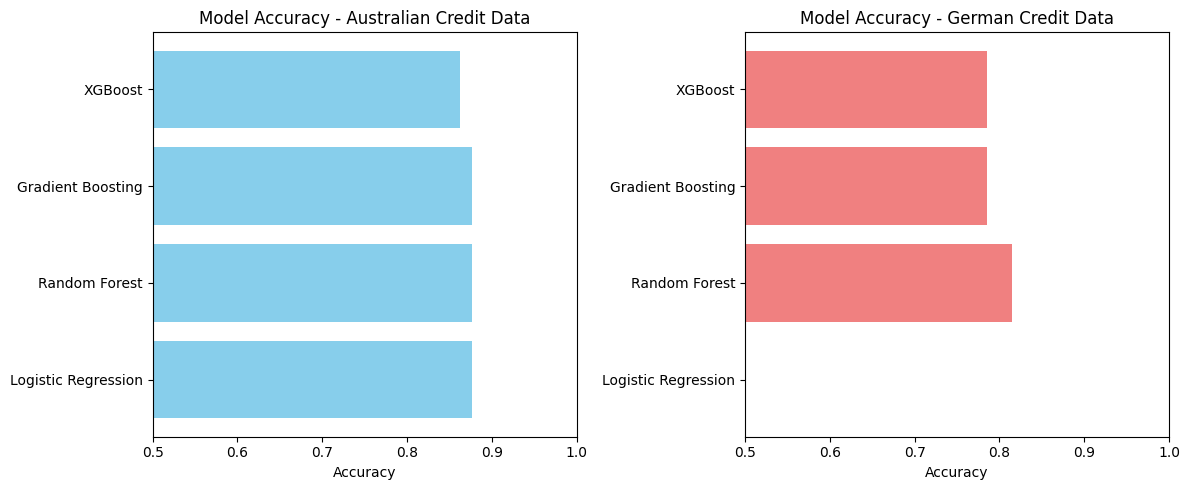

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ["Logistic Regression", "Random Forest", "Gradient Boosting", "XGBoost"]

# Australian Credit Model Accuracies
accuracy_australian = [
    accuracy_score(y_test_a, y_pred_a),
    accuracy_score(y_test_a, y_pred_rf_a),
    accuracy_score(y_test_a, y_pred_gb_a),
    accuracy_score(y_test_a, y_pred_xgb_a)
]

# German Credit Model Accuracies
accuracy_german = [
    accuracy_score(y_test_g, y_pred_g),
    accuracy_score(y_test_g, y_pred_rf_g),
    accuracy_score(y_test_g, y_pred_gb_g),
    accuracy_score(y_test_g, y_pred_xgb_g)
]

# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].barh(models, accuracy_australian, color="skyblue")
ax[0].set_title("Model Accuracy - Australian Credit Data")
ax[0].set_xlabel("Accuracy")
ax[0].set_xlim(0.5, 1.0)

ax[1].barh(models, accuracy_german, color="lightcoral")
ax[1].set_title("Model Accuracy - German Credit Data")
ax[1].set_xlabel("Accuracy")
ax[1].set_xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

Next Steps for Credit Risk Model

We will now:


*    Perform Hyperparameter Tuning using Grid Search and Random Search.
*    Analyze Feature Importance using SHAP (SHapley Additive Explanations).
*    Prepare for Deployment by saving the best model.

Step 1: Hyperparameter Tuning (Grid Search & Random Search)
We will tune the hyperparameters for Random Forest, Gradient Boosting, and XGBoost using Grid Search (exhaustive search) and Random Search (faster alternative).

Install Required Libraries

In [ ]:
!pip install scikit-learn xgboost shap

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

# Define hyperparameter grids
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10]
}

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10]
}

# Use Randomized Search for efficiency
random_search_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, n_iter=5, cv=3, scoring='accuracy', n_jobs=-1)
random_search_gb = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, n_iter=5, cv=3, scoring='accuracy', n_jobs=-1)
random_search_xgb = RandomizedSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), param_grid_xgb, n_iter=5, cv=3, scoring='accuracy', n_jobs=-1)

# Train on Australian dataset (faster)
random_search_rf.fit(X_train_a, y_train_a)
random_search_gb.fit(X_train_a, y_train_a)
random_search_xgb.fit(X_train_a, y_train_a)

# Print best parameters
print("Best Random Forest Params:", random_search_rf.best_params_)
print("Best Gradient Boosting Params:", random_search_gb.best_params_)
print("Best XGBoost Params:", random_search_xgb.best_params_)

# Train best models
best_rf = random_search_rf.best_estimator_
best_gb = random_search_gb.best_estimator_
best_xgb = random_search_xgb.best_estimator_

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:30:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Random Forest Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}
Best Gradient Boosting Params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best XGBoost Params: {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1}


Step 2: SHAP Feature Importance Analysis

SHAP helps explain which features contribute most to predictions.

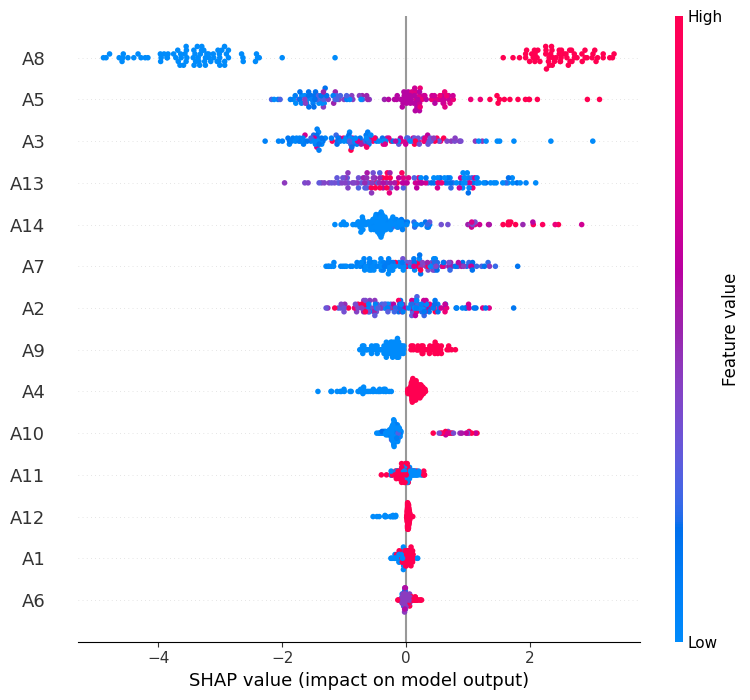

In [ ]:
import shap

# SHAP Analysis for XGBoost (best model)
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test_a)

# Plot feature importance
shap.summary_plot(shap_values, X_test_a, feature_names=X_australian.columns)


Step 3: Deploying the Best Model

We save the best-performing model using joblib.

In [ ]:
import joblib

# Save the best model
joblib.dump(best_xgb, "credit_risk_model.pkl")
print("Best model saved as 'credit_risk_model.pkl'")


Best model saved as 'credit_risk_model.pkl'


web dashboard for credit risk assessment using Streamlit. This will allow users to input customer financial details and predict their credit risk based on our trained machine learning model.

Create the Web Dashboard

We'll create a Streamlit app that allows users to enter financial details, and it will predict credit approval (Good/Bad Credit) using our trained XGBoost model.


In [ ]:
pip install streamlit joblib pandas scikit-learn xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load the trained model
model = joblib.load("credit_risk_model.pkl")

# Streamlit App Title
st.title("Credit Risk Assessment Dashboard")

# Sidebar User Input
st.sidebar.header("Enter Financial Details")

# Function to take user input
def user_input_features():
    Status = st.sidebar.selectbox("Status of Checking Account", [0, 1, 2, 3])
    Duration = st.sidebar.slider("Loan Duration (Months)", 6, 72, 24)
    CreditHistory = st.sidebar.selectbox("Credit History", [0, 1, 2, 3, 4])
    Purpose = st.sidebar.selectbox("Loan Purpose", [0, 1, 2, 3, 4, 5, 6, 7])
    CreditAmount = st.sidebar.slider("Credit Amount", 250, 20000, 5000)
    Savings = st.sidebar.selectbox("Savings Account", [0, 1, 2, 3, 4])
    Employment = st.sidebar.selectbox("Years Employed", [0, 1, 2, 3, 4])
    InstallRate = st.sidebar.slider("Installment Rate", 1, 4, 2)
    Age = st.sidebar.slider("Age", 18, 75, 30)
    ExistingCredits = st.sidebar.slider("Existing Credits", 1, 4, 1)

    # Create DataFrame for Model
    features = pd.DataFrame([[Status, Duration, CreditHistory, Purpose, CreditAmount, Savings, Employment, InstallRate, Age, ExistingCredits]],
                            columns=["Status", "Duration", "CreditHistory", "Purpose", "CreditAmount", "Savings", "Employment", "InstallRate", "Age", "ExistingCredits"])
    return features

# Get user input
input_data = user_input_features()

# Display input data
st.subheader("User Input:")
st.write(input_data)

# Predict Credit Risk
if st.button("Predict Credit Risk"):
    prediction = model.predict(input_data)
    result = "Good Credit (Low Risk)" if prediction[0] == 1 else "Bad Credit (High Risk)"

    # Display result
    st.subheader("Prediction Result:")
    st.write(f"**{result}**")

    # Confidence Score
    probability = model.predict_proba(input_data)[0]
    st.write(f"Confidence Score: **{round(probability[1] * 100, 2)}%**")

# Footer
st.markdown("Developed by **Mphikeleli Mathonsi** | Credit Risk Assessment Model")

2025-03-16 08:33:53.600 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-16 08:33:53.812 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-03-16 08:33:53.814 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-16 08:33:53.815 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-16 08:33:53.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-16 08:33:53.818 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-16 08:33:53.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-16 08:33:53.822 Thread 'MainThread': mi

DeltaGenerator()

In [ ]:
!pip install streamlit joblib pandas scikit-learn xgboost pyngrok

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load("credit_risk_model.pkl")

st.title("Credit Risk Assessment Dashboard")

st.sidebar.header("Enter Financial Details")

def user_input_features():
    Status = st.sidebar.selectbox("Status of Checking Account", [0, 1, 2, 3])
    Duration = st.sidebar.slider("Loan Duration (Months)", 6, 72, 24)
    CreditHistory = st.sidebar.selectbox("Credit History", [0, 1, 2, 3, 4])
    Purpose = st.sidebar.selectbox("Loan Purpose", [0, 1, 2, 3, 4, 5, 6, 7])
    CreditAmount = st.sidebar.slider("Credit Amount", 250, 20000, 5000)
    Savings = st.sidebar.selectbox("Savings Account", [0, 1, 2, 3, 4])
    Employment = st.sidebar.selectbox("Years Employed", [0, 1, 2, 3, 4])
    InstallRate = st.sidebar.slider("Installment Rate", 1, 4, 2)
    Age = st.sidebar.slider("Age", 18, 75, 30)
    ExistingCredits = st.sidebar.slider("Existing Credits", 1, 4, 1)

    features = pd.DataFrame([[Status, Duration, CreditHistory, Purpose, CreditAmount, Savings, Employment, InstallRate, Age, ExistingCredits]],
                            columns=["Status", "Duration", "CreditHistory", "Purpose", "CreditAmount", "Savings", "Employment", "InstallRate", "Age", "ExistingCredits"])
    return features

input_data = user_input_features()

st.subheader("User Input:")
st.write(input_data)

if st.button("Predict Credit Risk"):
    prediction = model.predict(input_data)
    result = "Good Credit (Low Risk)" if prediction[0] == 1 else "Bad Credit (High Risk)"

    st.subheader("Prediction Result:")
    st.write(f"**{result}**")

    probability = model.predict_proba(input_data)[0]
    st.write(f"Confidence Score: **{round(probability[1] * 100, 2)}%**")

st.markdown("Developed by **Mphikeleli Mathonsi** | Credit Risk Assessment Model")


Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.127.65.18:8501

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://vast-fans-jam.loca.lt
/root/.npm/_npx/75ac80b86e83d4a2/node_modules/localtunnel/bin/lt.js:81
    throw err;
    ^

Error: connection refused: localtunnel.me:15415 (check your firewall settings)
    at Socket.<anonymous> (/root/.npm/_npx/75ac80b86e83d4a2/node_modules/localtunnel/lib/TunnelCluster.js:52:11)
    at Socket.emit (node:events:517:28)
    at emitErrorNT (node:internal/streams/destroy:151:8)
    at emitErrorCloseNT (node:internal/streams/destroy:116:3)
    at process.processTicksAndRejections (node:internal/process/task_queues:82:21)

Node.js v18.20.5
⠙

In [ ]:
y_pred_xgb_a